# Xây dựng Kiến trúc MetaBlock Fusion (Gated Attention)

- **Bản chất**: Dữ liệu Tuổi/Vị trí không cộng dồn nữa, mà kích hoạt một lớp Màng lọc `Sigmoid Gate`, làm tăng/giảm sự chi tiết của Dữ liệu Ảnh.
- **Interpretability**: Lấy được số liệu Cổng Gate Attention để biết được Dữ liệu Bảng đóng góp bao nhiêu vào Bức ảnh.

In [1]:
import sys; sys.path.append('../..')
import torch
import torch.nn as nn
import torch.nn.functional as F
from _shared_fusion_env import get_dataloaders, get_device
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import timm
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, roc_auc_score
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Thu viện Grad-CAM XAI
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = get_device()
train_loader, test_loader, weights, tab_dim = get_dataloaders(batch_size=32, use_advanced_aug=True, data_folder='data_no_smote')
weights = weights.to(device)
print(f"Device: {device} | Tabular Dim: {tab_dim}")




Device: mps | Tabular Dim: 58


/Users/hhh/workspace/School/PBL7/src/Model_training/MetaBlock_Fusion/Advanced_Augmentation/../../_shared_fusion_env.py:75: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=16, max_width=16, min_holes=2, min_height=8, min_width=8, p=0.5),
/Users/hhh/workspace/School/PBL7/src/Model_training/MetaBlock_Fusion/Advanced_Augmentation/../../_shared_fusion_env.py:75: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=16, max_width=16, min_holes=2, min_height=8, min_width=8, p=0.5),


In [2]:
class MetaBlockFusionModel(nn.Module):
    def __init__(self, tab_dim, num_classes=6):
        super().__init__()
        # Xương sống PiT-Small
        self.img_net = timm.create_model('pit_s_distilled_224', pretrained=True, num_classes=0)
        
        self.tab_proj = nn.Sequential(
            nn.Linear(tab_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512)
        )
        self.img_proj = nn.Sequential(
            nn.Linear(576, 512),
            nn.BatchNorm1d(512),
            nn.ReLU()
        )
        
        self.attention_gate = nn.Sequential(
            nn.Linear(512 + 512, 512),
            nn.Sigmoid()
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, img, tab, return_gate=False):
        f_img_raw = self.img_net(img) # PiT returns (B, 576) directly
        
        f_img = self.img_proj(f_img_raw)
        f_tab = self.tab_proj(tab)
        
        combined = torch.cat([f_img, f_tab], dim=1)
        gate = self.attention_gate(combined)
        fused = gate * f_img + (1.0 - gate) * f_tab
        
        out = self.classifier(fused)
        if return_gate:
            return out, gate
        return out



In [3]:
model = MetaBlockFusionModel(tab_dim).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

E1, E2 = 10, 140
# Giai đoạn 1: Luyện tập Meta Block
for param in model.img_net.parameters(): param.requires_grad = False
opt1 = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, momentum=0.9, weight_decay=1e-3)

print("=== Phase 1: Attention Module Training (SGD) ===")
for ep in range(E1):
    model.train()
    running_loss = 0.0
    for imgs, tabs, lbls in tqdm(train_loader, leave=False):
        imgs, tabs, lbls = imgs.to(device), tabs.to(device), lbls.to(device)
        opt1.zero_grad()
        out = model(imgs, tabs)
        loss = criterion(out, lbls) 
        loss.backward()
        opt1.step()
        running_loss += loss.item()
    print(f"Epoch {ep+1}/{E1} | Train Loss: {running_loss/len(train_loader):.4f}")

# Giai đoạn 2: Bấm nút Unfreeze và ReduceLROnPlateau
for param in model.parameters(): param.requires_grad = True
opt2 = torch.optim.SGD(model.parameters(), lr=1e-4, momentum=0.9, weight_decay=1e-3)
scheduler2 = ReduceLROnPlateau(opt2, mode='max', patience=10, factor=0.1, min_lr=1e-6)
history = {'train_loss':[], 'val_bcc': [], 'val_auc': [], 'val_f1': []}

print("\n=== Phase 2: End-to-end Fine-tuning w/ ReduceLROnPlateau ===")
best_bcc = 0.0
patience = 15 # Chờ SGD khá lâu
stagnant = 0
import os
os.makedirs('../../../saved_models', exist_ok=True)
best_model_path = '../../../saved_models/nosmote_pit_best.pth'

for ep in range(E2):
    model.train()
    running_loss = 0.0
    for imgs, tabs, lbls in tqdm(train_loader, leave=False):
        imgs, tabs, lbls = imgs.to(device), tabs.to(device), lbls.to(device)
        opt2.zero_grad()
        out = model(imgs, tabs)
        loss = criterion(out, lbls)
        loss.backward()
        opt2.step()
        running_loss += loss.item()
    
    # --- EVALUATION LOOP ---
    model.eval()
    preds, trues, probs = [], [], []
    with torch.no_grad():
        for imgs, tabs, lbls in test_loader:
            out = model(imgs.to(device), tabs.to(device))
            _, y_hat = torch.max(out, 1)
            preds.extend(y_hat.cpu().numpy())
            trues.extend(lbls.numpy())
            probs.extend(F.softmax(out, dim=1).cpu().numpy())
            
    val_bcc = balanced_accuracy_score(trues, preds)
    val_f1 = f1_score(trues, preds, average='macro')
    try:
        val_auc = roc_auc_score(trues, probs, multi_class='ovr')
    except Exception:
        val_auc = 0.0
    current_lr = opt2.param_groups[0]['lr']
    
    t_loss = running_loss/len(train_loader)
    history['train_loss'].append(t_loss)
    history['val_bcc'].append(val_bcc)
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_f1)
    
    print(f"Epoch {ep+E1+1}/{E1+E2} | Train Loss: {t_loss:.4f} | Val BCC: {val_bcc*100:.2f}% | Val AUC: {val_auc:.4f} | LR: {current_lr:.2e}")
    
    scheduler2.step(val_bcc) # Feed metric here!!
    
    if val_bcc > best_bcc:
        best_bcc = val_bcc
        stagnant = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"   --> [+] Đỉnh cao mới BCC: {val_bcc*100:.2f}%! Đã lưu Checkpoint.")
    else:
        stagnant += 1
        if stagnant >= patience:
            print(f"   --> [-] Early Stopping kích hoạt. Khôi phục tự động mô hình tốt nhất...")
            model.load_state_dict(torch.load(best_model_path))
            break




=== Phase 1: Attention Module Training (SGD) ===


/Users/hhh/workspace/School/PBL7/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/57 [00:07<?, ?it/s]

Epoch 1/10 | Train Loss: 2.1489


  0%|          | 0/57 [00:00<?, ?it/s]

...

Epoch 81/150 | Train Loss: 0.5136 | Val BCC: 71.80% | Val AUC: 0.9226 | LR: 1.00e-06


  0%|          | 0/57 [00:00<?, ?it/s]

Epoch 82/150 | Train Loss: 0.5320 | Val BCC: 66.70% | Val AUC: 0.9226 | LR: 1.00e-06


  0%|          | 0/57 [00:00<?, ?it/s]

Epoch 83/150 | Train Loss: 0.5125 | Val BCC: 71.15% | Val AUC: 0.9223 | LR: 1.00e-06
   --> [-] Early Stopping kích hoạt. Khôi phục tự động mô hình tốt nhất...


  0%|          | 0/15 [00:00<?, ?it/s]


✅ Đánh giá Mô hình trên Tập Test:
 - F1-Macro Score: 0.7198
 - Balanced Accuracy (BCC): 0.7354
 - MACC-AUC (OvR): 0.9222

ROC-AUC Từng Lớp:
 - Lớp ACK: 0.9376
 - Lớp BCC: 0.8886
 - Lớp MEL: 0.9991
 - Lớp NEV: 0.9730
 - Lớp SCC: 0.7510
 - Lớp SEK: 0.9839


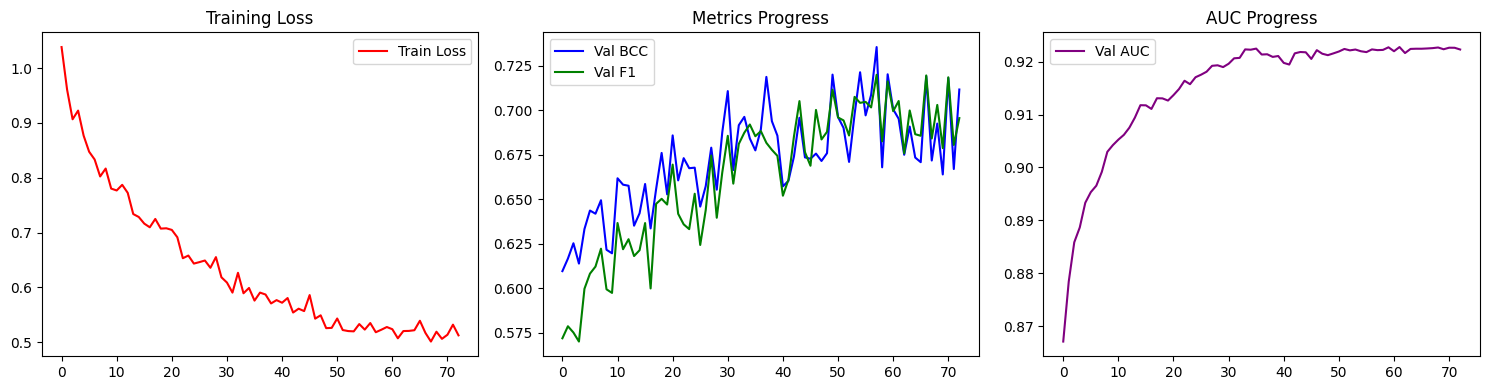

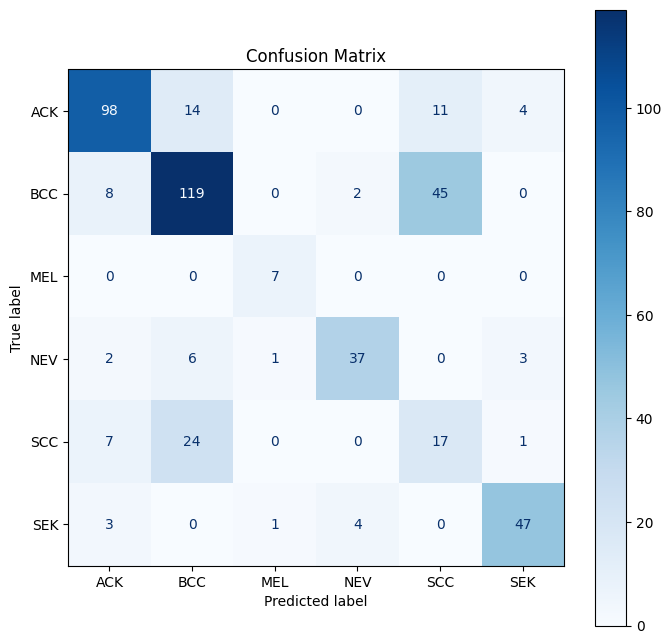

In [4]:
model.eval()
preds, trues, probs = [], [], []
with torch.no_grad():
    for imgs, tabs, lbls in tqdm(test_loader):
        out = model(imgs.to(device), tabs.to(device))
        _, y_hat = torch.max(out, 1)
        preds.extend(y_hat.cpu().numpy())
        trues.extend(lbls.numpy())
        probs.extend(F.softmax(out, dim=1).cpu().numpy())

f1 = f1_score(trues, preds, average='macro')
bcc = balanced_accuracy_score(trues, preds)
auc_macro = roc_auc_score(trues, probs, multi_class='ovr', average='macro')

print(f"\n✅ Đánh giá Mô hình trên Tập Test:")
print(f" - F1-Macro Score: {f1:.4f}")
print(f" - Balanced Accuracy (BCC): {bcc:.4f}")
print(f" - MACC-AUC (OvR): {auc_macro:.4f}")

from sklearn.preprocessing import label_binarize
Y_bin = label_binarize(trues, classes=[0,1,2,3,4,5])
probs_arr = np.array(probs)
class_names = ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
print("\nROC-AUC Từng Lớp:")
for i in range(6):
    class_auc = roc_auc_score(Y_bin[:, i], probs_arr[:, i])
    print(f" - Lớp {class_names[i]}: {class_auc:.4f}")

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss', color='red')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['val_bcc'], label='Val BCC', color='blue')
plt.plot(history['val_f1'], label='Val F1', color='green')
plt.title('Metrics Progress')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['val_auc'], label='Val AUC', color='purple')
plt.title('AUC Progress')
plt.legend()
plt.tight_layout()
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix(trues, preds), display_labels=class_names)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix')
plt.show()


## Lưu Mô hình (Model Checkpoint)
Bảo toàn Trọng số học được (Weights) để phục vụ cho Test độc lập hoặc Triển khai Web App/Mobile sau này mà không cần Train lại.

In [5]:
import os
os.makedirs('../../../saved_models', exist_ok=True)
save_path = '../../../saved_models/metablock_fusion.pth'
torch.save(model.state_dict(), save_path)
print(f"✅ Đã lưu trọng số mô hình tại: {save_path}")


✅ Đã lưu trọng số mô hình tại: ../../../saved_models/metablock_fusion.pth


In [6]:
# --- BÁO CÁO CHI TIẾT TỪNG NHÃN (CLASS-WISE) ---
model.load_state_dict(torch.load(best_model_path))
model.eval()
final_preds, final_trues = [], []
with torch.no_grad():
    for imgs, tabs, lbls in test_loader:
        out = model(imgs.to(device), tabs.to(device))
        _, y_hat = torch.max(out, 1)
        final_preds.extend(y_hat.cpu().numpy())
        final_trues.extend(lbls.numpy())

from sklearn.metrics import classification_report
print("=== BÁO CÁO F1, RECALL THEO TỪNG NHÃN QUAN TRỌNG (BEST MODEL) ===")
print(classification_report(final_trues, final_preds, digits=4))


=== BÁO CÁO F1, RECALL THEO TỪNG NHÃN QUAN TRỌNG (BEST MODEL) ===
              precision    recall  f1-score   support

           0     0.8305    0.7717    0.8000       127
           1     0.7301    0.6839    0.7062       174
           2     0.7778    1.0000    0.8750         7
           3     0.8605    0.7551    0.8043        49
           4     0.2329    0.3469    0.2787        49
           5     0.8545    0.8545    0.8545        55

    accuracy                         0.7050       461
   macro avg     0.7144    0.7354    0.7198       461
weighted avg     0.7343    0.7050    0.7173       461

